In [4]:
import os, sys, warnings
import numpy as np
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from linear_shock_functions import data_path, data_path, load_PF_starts
from linear_shock_variables import num_CA3_neurons, rest_time
from stat_functions import *
from plots import *

base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
sys.path.insert(0, os.path.join(base_path, "code/functions"))
plot_path = os.path.join(data_path, "plots")
os.makedirs(plot_path, exist_ok=True)

save_plot = True

## Parameters

In [5]:
cue_state = 3
sim_duration = rest_time//2   # ms
trial_number = 10
trial_dirs = [os.path.join(data_path, "trial%d" % i) for i in range(trial_number)]


## Load simulation results for all 10 Wu et al. shock exposures

Generated by `generate_data.ipynb` (`run_offline.simulate_fatigued_replay`); see the note under "Parameters" above.


## Analysis: forward vs. backward spike rate

In [6]:
from tqdm import tqdm
EC_coeff_list = [0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5]
PF_dict = load_PF_starts()
results = []
for trial in tqdm(range(trial_number),desc="Trial: "):
    exp_dir = trial_dirs[trial]
    temp_list = []
    for EC_coeff in EC_coeff_list:
        temp_f = dict(np.load(os.path.join(exp_dir, "CA3_replay_EC_%.1f.npz"%EC_coeff)))
        temp_list.append({
            "spike_times":     temp_f["spike_times_CA3_PC"],
            "spiking_neurons": temp_f["spiking_neurons_CA3_PC"],
            "rate":            temp_f["rate_PC"],
            "cue_idx":  temp_f["cue_neuron_ids"]
        })
    results.append(temp_list)

Trial: 100%|██████████| 10/10 [00:00<00:00, 232.74it/s]


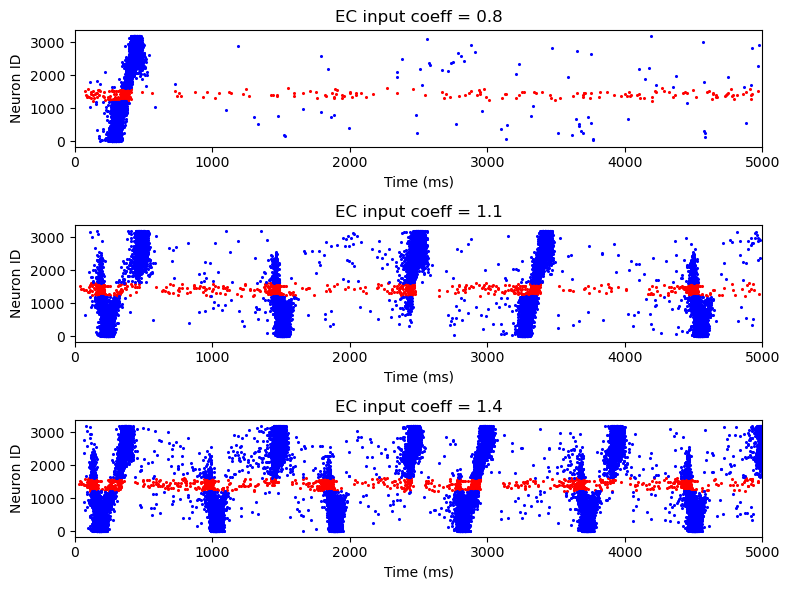

In [7]:
fig, axes = plt.subplots(3,1, figsize=(8, 6))
axes = axes.flatten()

target_seed = 0; target_EC_idx = [0,3,-2]

for ii, EC_idx in enumerate(target_EC_idx):
    plot_spike(results[target_seed][EC_idx]['spike_times'], results[target_seed][EC_idx]['spiking_neurons'],
               np.arange(num_CA3_neurons), zoom_to=5000, ax=axes[ii],
               cue_idx=results[target_seed][EC_idx]['cue_idx'])
    axes[ii].set_title("EC input coeff = %.1f"%EC_coeff_list[EC_idx])

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "EC_modulated_replay_juxtapose.pdf"),
            bbox_inches="tight")
plt.show()

In [8]:
from common_functions import slice_high_activity
replay_count = np.zeros((len(EC_coeff_list),trial_number))
replay_len = np.zeros_like(replay_count)
for trial in range(trial_number):
    for ee, coeff in enumerate(EC_coeff_list):
        rate_PC = results[trial][ee]["rate"]
        temp = slice_high_activity(rate_PC, th=2.0, min_len=128, len_sim=5000)
        
        temp_time = [tt[1]-tt[0] for tt in temp]
        replay_count[ee,trial] = len(temp)
        if len(temp) != 0: replay_len[ee,trial] = np.mean(temp_time)

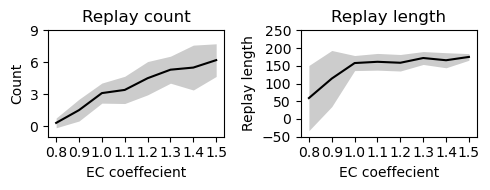

Statistics: Replay count, Mann-Kendall test
Mann_Kendall_Test(trend='increasing', h=True, p=0.0008366271311193163, z=3.340383700311406, Tau=1.0, s=28.0, var_s=65.33333333333333, slope=0.7999999999999999, intercept=1.1500000000000004)
Statistics: Replay length, Mann-Kendall test
Mann_Kendall_Test(trend='increasing', h=True, p=0.0044340083031007005, z=2.8455120410060126, Tau=0.8571428571428571, s=24.0, var_s=65.33333333333333, slope=9.763591269841267, intercept=125.75243055555558)


In [9]:
fig, axes = plt.subplots(1,2,figsize=(5,2))

xx = np.arange(len(EC_coeff_list))
plot_shaded(xx, replay_count.mean(-1), replay_count.std(-1), axes[0], color='black')
plot_shaded(xx, replay_len.mean(-1), replay_len.std(-1), axes[1], color='black')
axes[0].set_xticks(xx);axes[0].set_xticklabels(EC_coeff_list)
axes[1].set_xticks(xx);axes[1].set_xticklabels(EC_coeff_list)
axes[0].set_xlabel("EC coeffecient"); axes[1].set_xlabel("EC coeffecient")
axes[0].set_ylabel("Count"); axes[1].set_ylabel("Replay length")
axes[0].set_ylim([-1,9]); axes[0].set_yticks(np.arange(0,10,3))
axes[1].set_ylim([-50,250]); axes[1].set_yticks(np.arange(-50,260,50))
axes[0].set_title("Replay count"); axes[1].set_title("Replay length")

plt.tight_layout()
if save_plot:
    plt.savefig(os.path.join(plot_path, "EC_modulated_replay_statistics.svg"),
            bbox_inches="tight")
plt.show()

import pymannkendall as mk
result = mk.original_test(replay_count.mean(-1))
print("Statistics: Replay count, Mann-Kendall test")
print(result)
result = mk.original_test(replay_len.mean(-1))
print("Statistics: Replay length, Mann-Kendall test")
print(result)
